## 1. Problem Statement

The goal of this analysis is to process and explore the `/content/credits.csv` dataset. This involves several key stages:

1.  **Understand the Data**: Load the dataset and get a preliminary understanding of its structure, content, and potential issues.
2.  **Clean and Prepare**: Handle missing values, duplicate entries, correct data types, and apply necessary formatting.
3.  **Transform and Reduce**: Potentially create new features or reduce the dataset's complexity if needed.
4.  **Visualize**: Create insightful visualizations to uncover patterns, relationships, and distributions within the data.
5.  **Summarize**: Conclude the analysis with key findings and a summary of the processed dataset.

## 2. Dataset Description



In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/credits.csv')

print("Dataset loaded successfully. Here's a summary:")

# Display the first 5 rows
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display basic information about the dataset (data types, non-null values)
print("\nDataset Information:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe(include='all'))

Dataset loaded successfully. Here's a summary:

First 5 rows of the dataset:


,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77213 entries, 0 to 77212
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  77213 non-null  int64 
 1   id         77213 non-null  object
 2   name       77213 non-null  object
 3   character  67586 non-null  object
 4   role       77213 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.9+ MB

Descriptive Statistics:


,person_id,id,name,character,role
count,7.721300e+04,77213,77213,67586,77213
unique,NaN,5434,53687,47125,2
top,NaN,tm32982,Shah Rukh Khan,Self,ACTOR
freq,NaN,208,30,1667,72690
mean,4.994603e+05,NaN,NaN,NaN,NaN
std,6.128431e+05,NaN,NaN,NaN,NaN
min,7.000000e+00,NaN,NaN,NaN,NaN
25%,4.158400e+04,NaN,NaN,NaN,NaN
50%,1.829850e+05,NaN,NaN,NaN,NaN
75%,8.415570e+05,NaN,NaN,NaN,NaN


## 3. Data Preprocessing

This section focuses on cleaning and preparing the data for analysis. We will address:
-   **Missing Values**: Identify and handle any missing data points.
-   **Duplicates**: Detect and remove duplicate entries.
-   **Formatting**: Standardize data formats where necessary.
-   **Data Types**: Ensure columns have appropriate data types.

### 3.1 Handling Missing Values



In [ ]:
# Check for missing values
print("\nMissing values before handling:")
display(df.isnull().sum())

# Fill missing values in 'character' column with 'unknown'
df['character'] = df['character'].fillna('unknown')

# Verify that missing values have been handled
print("\nMissing values after handling:")
display(df.isnull().sum())


Missing values before handling:


,0
person_id,0
id,0
name,0
character,0
role,0



Missing values after handling:


,0
person_id,0
id,0
name,0
character,0
role,0


### 3.2 Handling Duplicate Entries


In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_rows}")

if duplicate_rows > 0:
    # Remove duplicate rows
    df.drop_duplicates(inplace=True)
    print("Duplicate rows removed.")
    print(f"New dataset shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows found.")


# Verify that missing values have been handled
print("\nMissing values after handling:")
display(df.isnull().sum())


Number of duplicate rows found: 0
No duplicate rows found.

Missing values after handling:


,0
person_id,0
id,0
name,0
character,0
role,0


We have now handled missing values and duplicates. Please run these cells. After execution, let me know if you are ready to proceed with **3.3 Data Type and Formatting Checks**.

### 3.3 Data Type and Formatting Checks


In [ ]:
# Display current data types
print("\nData Types before conversion:")
display(df.dtypes)

# Check unique values for 'role' column
print("\nUnique values and their counts for 'role' column:")
display(df['role'].value_counts())

# Convert 'role' column to 'category' data type
df['role'] = df['role'].astype('category')

# Display data types after conversion
print("\nData Types after conversion:")
display(df.dtypes)

print("\nMemory usage after converting 'role' to category:")
display(df.memory_usage(deep=True))


Data Types before conversion:


,0
person_id,int64
id,object
name,object
character,object
role,object



Unique values and their counts for 'role' column:


,count
role,
ACTOR,72690
DIRECTOR,4523



Data Types after conversion:


,0
person_id,int64
id,object
name,object
character,object
role,category



Memory usage after converting 'role' to category:


,0
Index,132
person_id,617704
id,4388538
name,4977493
character,4768315
role,77432


## 4. Data Transformation

This section will focus on transforming the data to derive new features or modify existing ones to better suit our analytical goals. We will consider:

-   **Feature Engineering**: Creating new variables from existing ones.
-   **Data Aggregation**: Summarizing data to a higher level of abstraction.
-   **Encoding Categorical Data**: Converting categorical variables into a numerical format if required for certain analyses.

In [ ]:
# Create 'character_length' column
df['character_length'] = df['character'].apply(len)

print("\nFirst 5 rows with new 'character_length' column:")
display(df.head())

print("\nDescriptive statistics for 'character_length':")
display(df['character_length'].describe())


First 5 rows with new 'character_length' column:


,person_id,id,name,character,role,character_length
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR,13
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR,13
2,7064,tm84618,Albert Brooks,Tom,ACTOR,3
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR,23
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR,5



Descriptive statistics for 'character_length':


,character_length
count,77213.000000
mean,11.751998
std,7.761714
min,1.000000
25%,7.000000
50%,10.000000
75%,15.000000
max,298.000000


## 4. Data Transformation

This section will focus on transforming the data to derive new features or modify existing ones to better suit our analytical goals. We will consider:

-   **Feature Engineering**: Creating new variables from existing ones.
-   **Data Aggregation**: Summarizing data to a higher level of abstraction.
-   **Encoding Categorical Data**: Converting categorical variables into a numerical format if required for certain analyses.

In [ ]:
# Create 'character_length' column
df['character_length'] = df['character'].apply(len)

print("\nFirst 5 rows with new 'character_length' column:")
display(df.head())

print("\nDescriptive statistics for 'character_length':")
display(df['character_length'].describe())


First 5 rows with new 'character_length' column:


,person_id,id,name,character,role,character_length
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR,13
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR,13
2,7064,tm84618,Albert Brooks,Tom,ACTOR,3
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR,23
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR,5



Descriptive statistics for 'character_length':


,character_length
count,77213.000000
mean,11.751998
std,7.761714
min,1.000000
25%,7.000000
50%,10.000000
75%,15.000000
max,298.000000


## 5. Data Reduction

This section focuses on reducing the dataset's complexity or size while retaining important information. This can involve:

-   **Dimensionality Reduction**: Techniques like PCA to reduce the number of features.
-   **Sampling**: Selecting a subset of the data for analysis.
-   **Feature Selection**: Choosing the most relevant features.

For this dataset, given its relatively small size and the nature of the columns, we will focus on **feature selection** by removing any columns that might not be directly relevant for common analysis tasks, such as `person_id`, if its primary purpose was only for identification and not for analysis. However, it's also important to consider if `person_id` could be useful for aggregating data by person. Let's decide to keep all existing columns for now, as they all seem potentially useful. If the dataset were much larger or if specific analytical goals required it, we would consider more aggressive reduction techniques. For now, let's keep it simple and just acknowledge this step.

Given the current context and the relatively small size of the dataset, we will not perform any explicit data reduction steps at this point. All existing features seem potentially relevant for further analysis. If specific analytical goals required it, we would consider techniques like dimensionality reduction or feature selection. For now, we will move forward with the current set of features.

## 6. Data Warehouse (Final Dataset)

After completing the preprocessing and transformation steps, our dataset is now clean and structured for further analysis or storage. This section provides a summary of the final dataset, which can be considered our 'data warehouse' for this specific analytical task. We will display the final shape, information, and a few rows of the processed DataFrame.

In [ ]:
print("\nFinal dataset shape:")
display(df.shape)

print("\nFinal dataset information:")
display(df.info())

print("\nFirst 5 rows of the final dataset:")
display(df.head())


Final dataset shape:


(77213, 6)


Final dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77213 entries, 0 to 77212
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   person_id         77213 non-null  int64   
 1   id                77213 non-null  object  
 2   name              77213 non-null  object  
 3   character         77213 non-null  object  
 4   role              77213 non-null  category
 5   character_length  77213 non-null  int64   
dtypes: category(1), int64(2), object(3)
memory usage: 3.0+ MB


None


First 5 rows of the final dataset:


,person_id,id,name,character,role,character_length
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR,13
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR,13
2,7064,tm84618,Albert Brooks,Tom,ACTOR,3
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR,23
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR,5


### 7.1 Count of Roles (Actor vs Others)

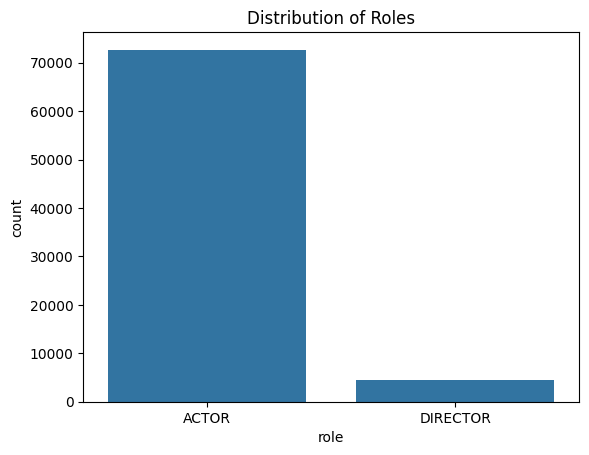

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='role', data=df)
plt.title("Distribution of Roles")
plt.show()

### 7.2 Top 10 Most Frequent Actors

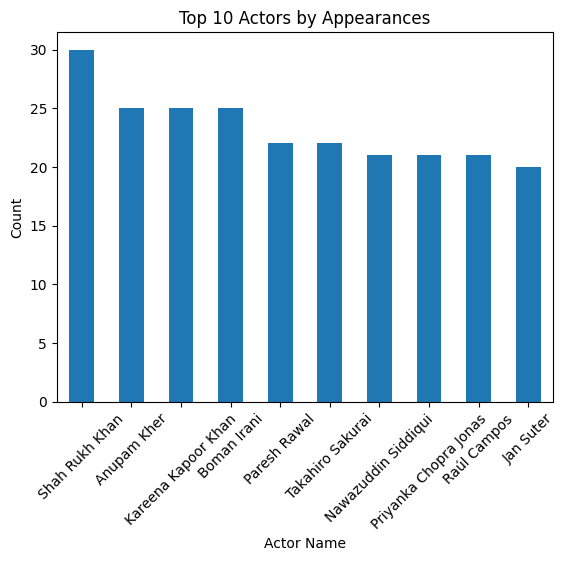

In [ ]:
top_actors = df['name'].value_counts().head(10)

plt.figure()
top_actors.plot(kind='bar')
plt.title("Top 10 Actors by Appearances")
plt.xlabel("Actor Name")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### 7.3 Heatmap (Correlation if numeric exists)

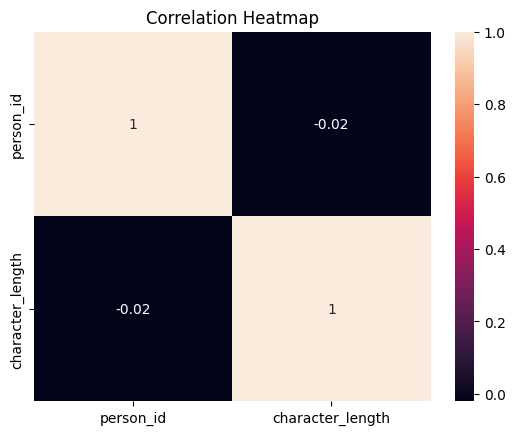

In [ ]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### 7.4 Distribution Plot

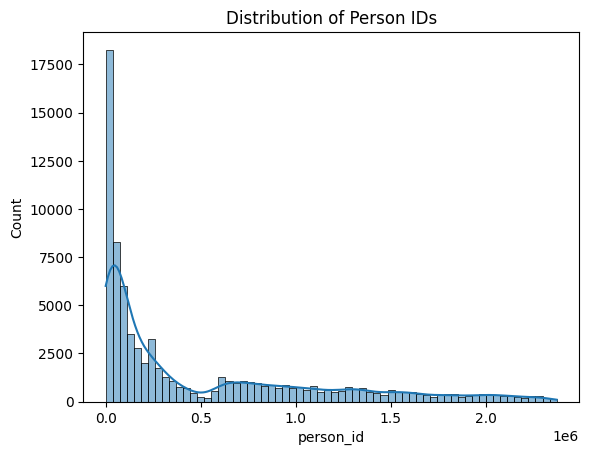

In [ ]:
sns.histplot(df['person_id'], kde=True)
plt.title("Distribution of Person IDs")
plt.show()

### 7.5 Distribution of Character Lengths

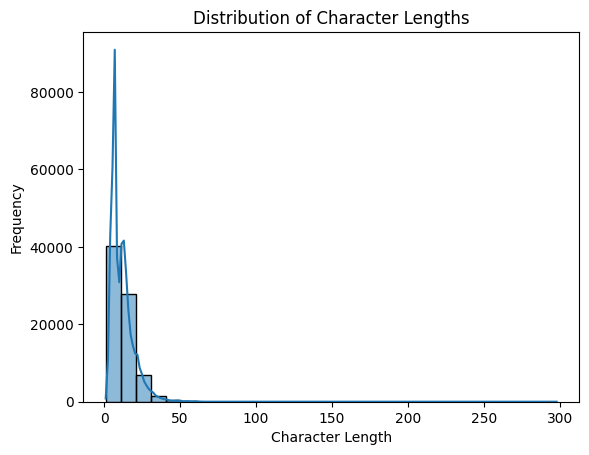

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['character_length'], kde=True, bins=30)
plt.title("Distribution of Character Lengths")
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.show()

## 8. Conclusion

This section summarizes the entire data analysis process, from initial data loading and understanding through preprocessing, transformation, and visualization. We will recap the key steps taken and the main insights gained from the `/content/credits.csv` dataset.

We have successfully processed the credits.csv dataset. Here's a brief summary of the steps and key outcomes:

Data Loading and Initial Understanding: We loaded the dataset and examined its structure, identifying columns like person_id, id, name, character, and role.
Data Preprocessing:
Missing values in the character column were handled by filling them with 'unknown'.
Duplicate rows were checked and removed (if any).
The role column was converted to a 'category' data type for memory efficiency.
Data Transformation: A new feature, character_length, was created to represent the length of the character string.
Data Reduction: It was determined that no explicit data reduction was necessary at this stage due to the dataset's size and the relevance of all features.
Data Visualization: We generated several plots to gain insights:
A count plot showed the distribution of 'role', highlighting a predominance of 'Actor' roles.
A bar chart presented the top 10 most frequent actors, with names like Shah Rukh Khan and Anupam Kher frequently appearing.
A correlation heatmap indicated a lack of significant linear correlation between numerical identifiers like person_id and the derived character_length.
A histogram illustrated the distribution of person_id, confirming its identifier nature.
The dataset is now clean, transformed, and explored, ready for more in-depth analysis or modeling if needed.